In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv(
    "../dataset/cleaned/clean_house_price_india.csv"
)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (13859, 24)


,id,date,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,...,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price,property_age
0,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,0,122005,52.9532,-114.321,3350,42847,3,76,838000,25
1,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,0,122006,52.9047,-114.485,2060,4500,1,51,805000,97
2,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,0,122007,52.9133,-114.590,2380,4750,1,67,790000,75
3,6762813157,42491,5,3.25,3660,11995,2.0,0,2,3,...,0,122008,52.7637,-114.050,3320,11241,3,72,785000,20
4,6762813599,42491,3,1.75,2240,10578,2.0,0,0,5,...,0,122006,52.9254,-114.482,1570,10578,3,71,750000,103


In [3]:
geo_features = df[
    [
        "lattitude",
        "longitude",
        "distance_from_the_airport",
        "number_of_schools_nearby",
        "waterfront_present",
        "number_of_views",
        "postal_code"
    ]
]


geo_features.head()

,lattitude,longitude,distance_from_the_airport,number_of_schools_nearby,waterfront_present,number_of_views,postal_code
0,52.9532,-114.321,76,3,0,0,122005
1,52.9047,-114.485,51,1,0,0,122006
2,52.9133,-114.590,67,1,0,0,122007
3,52.7637,-114.050,72,3,0,2,122008
4,52.9254,-114.482,71,3,0,0,122006


In [4]:
geo_features.describe()

,lattitude,longitude,distance_from_the_airport,number_of_schools_nearby,waterfront_present,number_of_views,postal_code
count,13859.000000,13859.000000,13859.000000,13859.000000,13859.000000,13859.000000,13859.000000
mean,52.789978,-114.403307,64.958078,2.011256,0.003247,0.172451,122032.932102
std,0.140031,0.142956,8.929482,0.816655,0.056892,0.643464,19.046708
min,52.385900,-114.709000,50.000000,1.000000,0.000000,0.000000,122003.000000
25%,52.698300,-114.521000,57.000000,1.000000,0.000000,0.000000,122017.000000
50%,52.801100,-114.422000,65.000000,2.000000,0.000000,0.000000,122031.000000
75%,52.910900,-114.313000,73.000000,3.000000,0.000000,0.000000,122048.000000
max,53.007600,-113.505000,80.000000,3.000000,1.000000,4.000000,122072.000000


In [5]:
df["geo_risk_score"] = (
    (df["number_of_schools_nearby"] * 0.25)
    +
    (df["number_of_views"] * 0.25)
    +
    (df["waterfront_present"] * 0.20)
    -
    (df["distance_from_the_airport"] * 0.0005)
)


In [6]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()


df["geo_risk_score"] = scaler.fit_transform(
    df[["geo_risk_score"]]
)


df[
    [
        "postal_code",
        "geo_risk_score"
    ]
].head()

,postal_code,geo_risk_score
0,122005,0.292711
1,122006,0.008455
2,122007,0.003790
3,122008,0.585423
4,122006,0.294169


In [7]:
def risk_category(score):
    if score < 0.33:
        return "Low Risk"
    elif score < 0.66:
        return "Medium Risk"
    else:
        return "High Potential"


df["location_rating"] = df["geo_risk_score"].apply(
    risk_category
)


df[
    [
        "postal_code",
        "geo_risk_score",
        "location_rating"
    ]
].head()

,postal_code,geo_risk_score,location_rating
0,122005,0.292711,Low Risk
1,122006,0.008455,Low Risk
2,122007,0.003790,Low Risk
3,122008,0.585423,Medium Risk
4,122006,0.294169,Low Risk


In [8]:
df["location_rating"].value_counts()

location_rating
Low Risk          13084
Medium Risk         615
High Potential      160
Name: count, dtype: int64

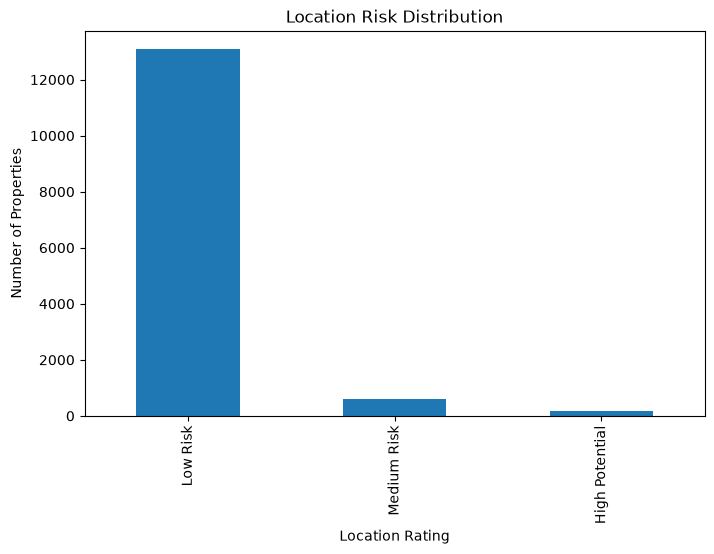

In [9]:
plt.figure(figsize=(8,5))

df["location_rating"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Location Risk Distribution"
)

plt.xlabel(
    "Location Rating"
)

plt.ylabel(
    "Number of Properties"
)

plt.show()

In [10]:
import os

os.makedirs(
    "../dataset/processed",
    exist_ok=True
)


df.to_csv(
    "../dataset/processed/geo_risk_features.csv",
    index=False
)


print("Geo Risk Dataset Saved Successfully!")

Geo Risk Dataset Saved Successfully!
